In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier
import shap
import joblib
import json



In [2]:
from pathlib import Path

# Root paths
project_path    = Path("../..").resolve()          # Project/
data_path       = project_path / "data"
processed_path  = data_path / "processed"          # colleague's files

# output paths
xai_path        = project_path / "XAI_2026"
models_path     = xai_path / "models"
artifacts_path  = xai_path / "artifacts"
outputs_path    = xai_path / "outputs"

# Create folders if they don't exist
models_path.mkdir(parents=True, exist_ok=True)
artifacts_path.mkdir(parents=True, exist_ok=True)
outputs_path.mkdir(parents=True, exist_ok=True)

print(f"  Reading data from : {processed_path}")
print(f"  Saving models to  : {models_path}")
print(f"  Saving arrays to  : {artifacts_path}")
print(f"  Saving plots to   : {outputs_path}")

  Reading data from : C:\Users\Kacpiro Recenzje\Desktop\Studia\XAI_2026\data\processed
  Saving models to  : C:\Users\Kacpiro Recenzje\Desktop\Studia\XAI_2026\XAI_2026\models
  Saving arrays to  : C:\Users\Kacpiro Recenzje\Desktop\Studia\XAI_2026\XAI_2026\artifacts
  Saving plots to   : C:\Users\Kacpiro Recenzje\Desktop\Studia\XAI_2026\XAI_2026\outputs


In [3]:
# Load data
df = pd.read_csv(f"{processed_path}\\ravdess_mfcc_features_v2.csv")

In [4]:
df

,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,mfcc_mean_10,...,mfcc_delta_std_34,mfcc_delta_std_35,mfcc_delta_std_36,mfcc_delta_std_37,mfcc_delta_std_38,mfcc_delta_std_39,mfcc_delta_std_40,Emotion,Emotion_ID,Path
0,-398.04220,75.356050,3.555152,13.388279,6.033112,15.046699,-3.274679,3.410381,-3.609158,-1.716895,...,0.666572,0.683853,0.649953,0.690861,0.616112,0.641250,0.650382,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
1,-404.41440,77.657196,1.182115,14.425774,8.691035,15.811256,-4.619638,4.848064,-4.008130,-4.158945,...,0.558050,0.517243,0.643897,0.560654,0.735399,0.663243,0.650409,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
2,-423.03020,75.066860,3.681056,12.329444,6.456292,11.320029,-3.664177,4.332827,-5.347966,-3.426528,...,0.715581,0.730944,0.651703,0.507533,0.522464,0.576221,0.716872,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
3,-431.44470,70.960460,5.918694,13.914023,6.412232,13.075801,-2.052994,5.827670,-5.217687,-3.630437,...,0.679620,0.560773,0.626818,0.622375,0.622986,0.500272,0.799045,neutral,5,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
4,-374.96695,88.756744,6.575492,16.645142,7.118174,16.783058,-3.964944,5.049708,-6.502435,-1.174364,...,0.624812,0.677422,0.675885,0.721127,0.824473,0.579583,0.562428,calm,1,C:\Users\shahe\4XAI\Project\data\raw\Actor_01\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-385.39197,52.095585,-22.968992,4.256605,-12.684442,-4.531819,-16.086650,-5.415159,-17.741135,-9.599253,...,1.285289,1.215589,1.262447,1.441106,1.409283,1.500882,1.266859,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1436,-369.15814,74.104320,-19.512238,3.407336,-18.050701,-5.426367,-22.706207,-6.697923,-13.299150,-11.602337,...,1.587545,1.677188,1.400912,1.257759,1.049124,1.029541,0.989744,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1437,-339.16750,70.145325,-28.976427,6.397467,-16.471600,-3.564403,-27.153255,-8.337615,-14.180528,-11.658910,...,1.431605,1.192082,1.419744,1.308439,1.488462,1.324050,1.054987,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...
1438,-345.55200,52.704910,-18.165882,15.100112,-14.326173,1.605802,-16.545298,0.559315,-16.987654,-3.354616,...,1.185229,1.364777,1.054514,1.022725,1.226704,0.876141,0.904909,surprise,7,C:\Users\shahe\4XAI\Project\data\raw\Actor_24\...


In [5]:
feature_cols = [c for c in df.columns
                if c.startswith("mfcc_")]                  # grabs all 160
X = df[feature_cols].values
print("Feature matrix shape:", X.shape)   


Feature matrix shape: (1440, 160)


In [6]:
y        = df["Emotion_ID"].values
y_text   = df["Emotion"].values
classes  = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']

print("Feature matrix shape:", X.shape)   # (1440, 40)
print("Labels shape:", y.shape)           # (1440,)

Feature matrix shape: (1440, 160)
Labels shape: (1440,)


In [7]:
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", sorted(classes))

Feature matrix shape: (1440, 160)
Labels shape: (1440,)
Classes: ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


C:\Users\Kacpiro Recenzje\AppData\Local\Temp\ipykernel_2236\1788335617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")


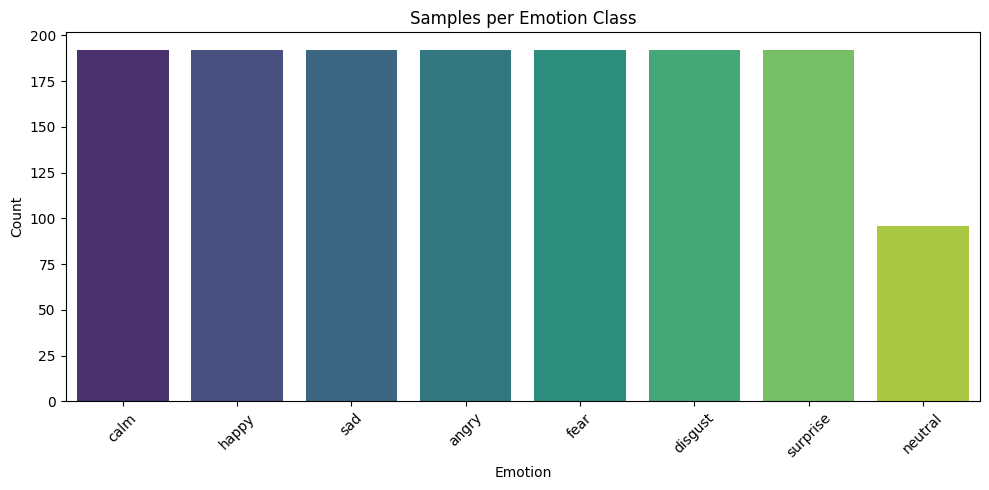

In [8]:
# Always check balance BEFORE training
emotion_counts = pd.Series(y_text).value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")
plt.title("Samples per Emotion Class")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Split & Scale

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Since neutral is underrepresented we used stratification to ensure consistent distribution across sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)   
print("Test size:",  X_test_scaled.shape) 

Train size: (1152, 160)
Test size: (288, 160)


# Cross Validation BEFORE Final Training

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV      
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────
# RANDOM FOREST TUNING
# ─────────────────────────────────────────

rf_param_grid = {
    'n_estimators':      randint(100, 500),     
    'max_depth':         [5, 10, 15, 20], 
    'min_samples_split': randint(2, 20),          
    'min_samples_leaf':  randint(1, 10),          
    'max_features':      ['sqrt', 'log2', 0.5]  
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,             
    cv=cv,                  
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,               
    verbose=1              
)
rf_search.fit(X_train_scaled, y_train)

print("="*50)
print("RANDOM FOREST - Best Parameters:")
print(rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.3f}")

# ─────────────────────────────────────────
# XGBOOST TUNING
# ─────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':     randint(100, 500),       
    'learning_rate':    uniform(0.01, 0.3),      
    'max_depth':        randint(3, 10),           
    'subsample':        uniform(0.6, 0.4),        
    'colsample_bytree': uniform(0.6, 0.4),        
    'min_child_weight': randint(1, 10),           
    'gamma':            uniform(0, 0.5) 
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=xgb_param_grid,
    n_iter=30,      
    cv=cv,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_scaled, y_train)

print("="*50)
print("XGBOOST - Best Parameters:")
print(xgb_search.best_params_)
print(f"Best CV F1: {xgb_search.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RANDOM FOREST - Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 406}
Best CV F1: 0.564
Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBOOST - Best Parameters:
{'colsample_bytree': np.float64(0.8497416192535173), 'gamma': np.float64(0.147816842918857), 'learning_rate': np.float64(0.041648277949081186), 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 385, 'subsample': np.float64(0.9533121035675474)}
Best CV F1: 0.633


In [11]:
print("\n" + "="*50)
print("TUNING SUMMARY")
print("="*50)
print(f"Random Forest best CV F1 : {rf_search.best_score_:.3f}")
print(f"XGBoost       best CV F1 : {xgb_search.best_score_:.3f}")

if xgb_search.best_score_ >= rf_search.best_score_:
    best_params  = xgb_search.best_params_
    best_name    = "XGBoost"
    print(f"\nWinner: XGBoost ")
else:
    best_params  = rf_search.best_params_
    best_name    = "Random Forest "
    print(f"\nWinner: Random Forest ")

print(f"Best Parameters: {best_params}")


TUNING SUMMARY
Random Forest best CV F1 : 0.564
XGBoost       best CV F1 : 0.633

Winner: XGBoost 
Best Parameters: {'colsample_bytree': np.float64(0.8497416192535173), 'gamma': np.float64(0.147816842918857), 'learning_rate': np.float64(0.041648277949081186), 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 385, 'subsample': np.float64(0.9533121035675474)}


# 5 - Train Final Models

In [12]:
# Automatically uses whatever won above
if best_name == "XGBoost":
    final_model = XGBClassifier(
        **xgb_search.best_params_,     # unpack best params directly
        random_state=42,
        eval_metric='mlogloss'
    )
else:
    final_model = RandomForestClassifier(
        **rf_search.best_params_,
        random_state=42,
        n_jobs=-1
    )

# NOW train permanently on full training set
final_model.fit(X_train_scaled, y_train)
print(f"Final {best_name} model trained ")

Final XGBoost model trained 


# 6 - Comprehensive Evaluation

In [13]:
y_pred = final_model.predict(X_test_scaled)

print("="*50)
print(f"FINAL {best_name} - Test Set Results")
print("="*50)
print(f"Accuracy:     {accuracy_score(y_test, y_pred):.3f}")
print(f"Weighted F1:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"Macro F1:     {f1_score(y_test, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=classes))

FINAL XGBoost - Test Set Results
Accuracy:     0.646
Weighted F1:  0.642
Macro F1:     0.631

              precision    recall  f1-score   support

       angry       0.59      0.79      0.67        38
        calm       0.63      0.63      0.63        38
     disgust       0.69      0.71      0.70        38
        fear       0.74      0.74      0.74        39
       happy       0.64      0.46      0.54        39
     neutral       0.50      0.42      0.46        19
         sad       0.59      0.63      0.61        38
    surprise       0.72      0.67      0.69        39

    accuracy                           0.65       288
   macro avg       0.64      0.63      0.63       288
weighted avg       0.65      0.65      0.64       288



### Interpretation

The gap between the CV F1 score and the Macro F1 score is very minimal (0.633 vs 0.631), which indicates that the model generalizes well for new data. In terms of recall the model does better with emotions that are often not monotone in voice, speed an tone like anger, fear and disgust. In terms of worst performers, we find out from the confusion matrix below that happiness is often confused for anger and fear, which makes sense. As for neutral the model struggles to classify it well, it may be due to the fact that the class is underrepresented or simply that the voice recordings for it do not contain much information for the model to train of off.

##  Confusion Matrix

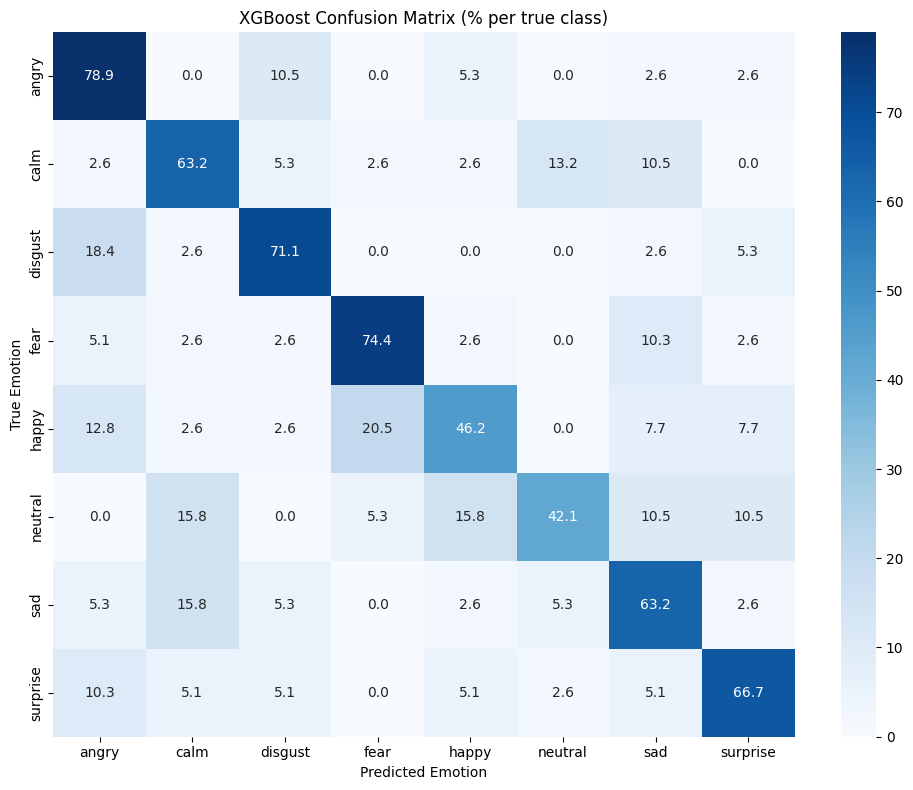

In [14]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title(f'{best_name} Confusion Matrix (% per true class)')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig(outputs_path / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis - Emotion by Emotion

### Strong Performers - Above Mean

#### Fear  
**F1 = 0.74**  
**Correctly classified:** 74.4%

- Main confusion: **sad** - 10.3%
- Fear remains one of the strongest recognized emotions
- It still shows overlap with another negative emotion



#### Surprise  
**F1 = 0.69**  
**Correctly classified:** 66.7%

- Main confusion: **angry** - 10.3%
- Both may contain sudden energy bursts



#### Disgust  
**F1 = 0.70**  
**Correctly classified:** 71.1%

- Main confusion: **angry** - 18.4%
- Both are negative emotions with high vocal tension



#### Angry  
**F1 = 0.67**  
**Correctly classified:** 78.9%

- Highest diagonal value in the confusion matrix
- Best recognized emotion overall
- Has a strong acoustic signature in MFCC features



## Weak Performers - Below Mean

#### Happy  
**F1 = 0.54**  
**Correctly classified:** 46.2%

- Worst-performing emotion
- Strong confusion with **fear** - 20.5%
- Interesting case: happy is often misclassified as fear
- Both may involve high pitch and high energy
- Mean MFCC features may not separate them clearly



#### Neutral  
**F1 = 0.46**  
**Correctly classified:** 42.1%

- Main confusion: **calm** and **happy** - 15.8% each
- Also confused with **sad** - 10.5%
- Acoustically flat emotions are harder to distinguish

## Key Patterns for SHAP Investigation

### Pattern 1 - High Arousal Confusion
**Fear/Happy confusion** (biggest surprise):
  Happy predicted as Fear:  20.5%
  Both emotions share:
    → High energy
    → High pitch
    → Fast speech rate
  Mean MFCCs see similar values for both

SHAP question: "Which MFCCs does model use to
               separate fear from happy?"

### Pattern 2 - Negative Emotion Confusion
**Disgust/Angry confusion**: 18.4%
  Both share:
    → Low pitch
    → High tension
    → Harsh vocal quality
  Model partially merges these two

SHAP question: "What separates disgust from angry
               in the MFCC space?"

### Pattern 3 - Low Arousal Confusion
**Calm/Neutral** - Sad bleeding into each other:
  Neutral → Calm: 15.8%
  Sad → Calm:     15.8%
  Calm → Neutral: 13.2%
  Calm → Sad:     10.5%

These three form a "quiet emotion cluster"
Mean MFCCs cannot separate them reliably

SHAP question: "Does the model even have distinct
               feature patterns for these three?"

## Per Emotion F1 Bar Chart

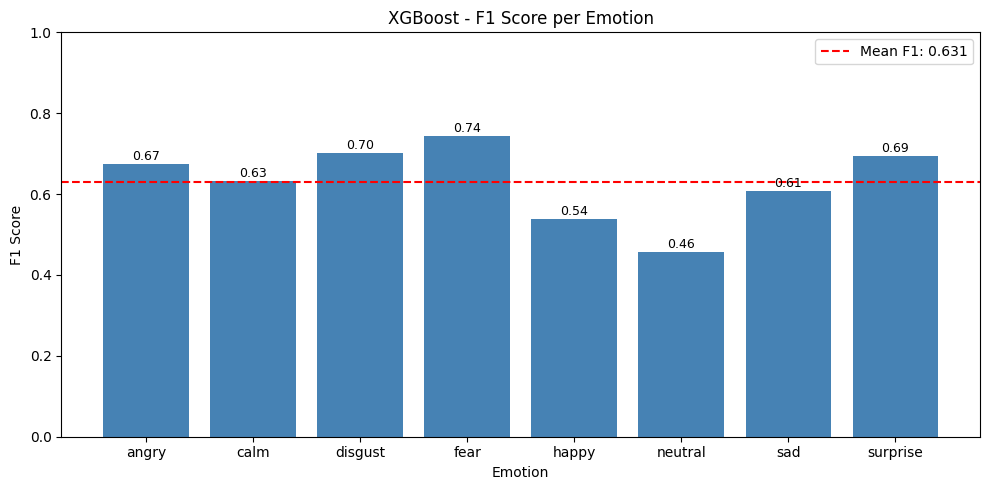

In [15]:
per_emotion_f1 = f1_score(y_test, y_pred, average=None)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, per_emotion_f1, color='steelblue')
plt.title(f'{best_name} - F1 Score per Emotion')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.axhline(y=per_emotion_f1.mean(), color='red',
            linestyle='--', label=f'Mean F1: {per_emotion_f1.mean():.3f}')
plt.legend()

for bar, val in zip(bars, per_emotion_f1):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(outputs_path / "per_emotion_f1.png", dpi=150, bbox_inches='tight')
plt.show()

## saving modeland scaler

In [16]:
# Models
joblib.dump(final_model, models_path / "xgb_final_model.pkl")
joblib.dump(scaler,      models_path / "scaler.pkl")
best_params_dict = {k: float(v) if hasattr(v, 'item') 
                    else v for k, v in xgb_search.best_params_.items()}
with open(models_path / "xgb_best_params.json", "w") as f:
    json.dump(best_params_dict, f, indent=4)

# Arrays
np.save(artifacts_path / "X_test_scaled.npy",  X_test_scaled)
np.save(artifacts_path / "X_train_scaled.npy", X_train_scaled)
np.save(artifacts_path / "y_test.npy",          y_test)
np.save(artifacts_path / "y_train.npy",         y_train)
np.save(artifacts_path / "y_pred.npy",          y_pred)



print("All saved to correct locations ")

All saved to correct locations 


In [17]:
# Loading the saved objects
final_model    = joblib.load(models_path    / "xgb_final_model.pkl")
scaler         = joblib.load(models_path    / "scaler.pkl")
X_test_scaled  = np.load(artifacts_path    / "X_test_scaled.npy")
y_test         = np.load(artifacts_path    / "y_test.npy")

# SHAP Analysis

### Setup SHAP

In [18]:
import shap

# Feature names for all 160 features
feature_names = (
    [f"mfcc_mean_{i+1}"       for i in range(40)] +
    [f"mfcc_std_{i+1}"        for i in range(40)] +
    [f"mfcc_delta_mean_{i+1}" for i in range(40)] +
    [f"mfcc_delta_std_{i+1}"  for i in range(40)]
)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (288, 160, 8)


In [19]:
feature_names = np.array(feature_names)  

print(type(feature_names))  
print(feature_names.shape)   

<class 'numpy.ndarray'>
(160,)


### 2 - Global Feature Importance (Overall)

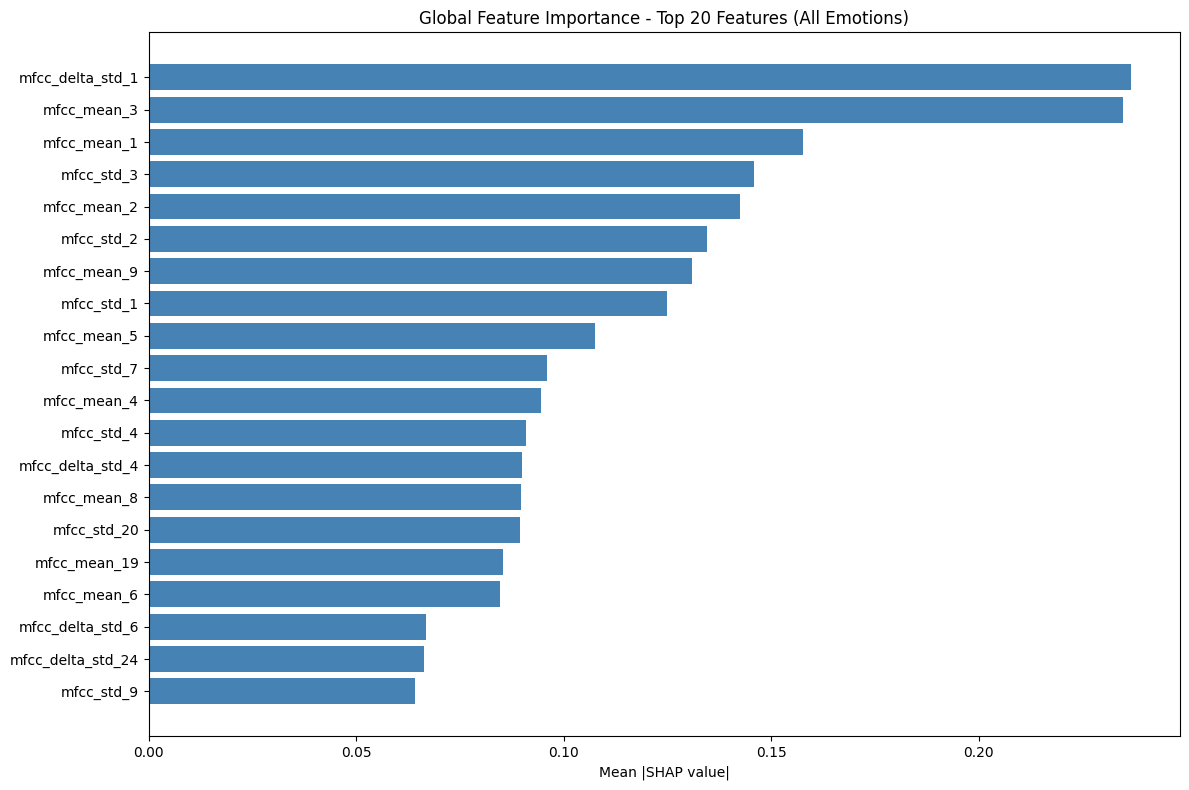

In [20]:
# Computing mean absolute SHAP across all emotions manually
mean_shap_all = np.abs(shap_values).mean(axis=(0, 2)) 

top20_idx   = np.argsort(mean_shap_all)[::-1][:20]
top20_vals  = mean_shap_all[top20_idx]
top20_names = feature_names[top20_idx]

plt.figure(figsize=(12, 8))
plt.barh(range(20), top20_vals[::-1], color='steelblue')
plt.yticks(range(20), top20_names[::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance - Top 20 Features (All Emotions)")
plt.tight_layout()
plt.savefig(outputs_path / "shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Most important findings from our XAI analysis - the Global Feature Importance plot generated using SHAP.
This bar chart answers a fundamental question: which acoustic features does our XGBoost model rely on most when identifying emotions?
Each bar represents one feature, and the length of the bar tells us how much that feature influences emotion predictions on average across all eight emotion classes. The longer the bar, the more globally important that feature is.

The first thing that stands out is our top two features - mfcc_mean_3 and mfcc_delta_std_1 - and what makes them remarkable is not just that they are the most important, but that they have very similar mean absolute SHAP values. A small difference between the top two features is a significant finding.
mfcc_mean_3 represents an average pattern captured by the third MFCC coefficient, which is related to the spectral shape of the voice. This feature captures what we can think of as part of the acoustic character of a person's voice. Acoustically, this makes sense. Emotions like anger and fear may show different patterns in this feature, while sad and neutral speech may show more subdued patterns. It is part of the acoustic fingerprint of emotional expression.
mfcc_delta_std_1, on the other hand, is a completely different type of feature. This is a dynamic, temporal feature - specifically, it measures variability in how the voice changes over time. In simple terms, it captures not only what the voice sounds like, but how unpredictably it moves. An angry speaker's voice may shift rapidly and forcefully. A calm speaker's voice may move steadily and smoothly. This feature captures part of that difference.

The fact that these two features - one static and one dynamic - have very similar importance tells us something profound: emotion cannot be fully described by tone alone. How the voice moves over time carries important information alongside what it sounds like at any given moment. This directly validates our decision to go beyond the original 40 mean MFCC features and add standard deviation and delta features. Without that engineering step, mfcc_delta_std_1 - one of the most important signals in the entire dataset - would have been completely invisible to our model.

Now, stepping back to look at the broader picture, our global SHAP analysis reveals two particularly strong characteristics of the model we trained.
The first is distributed importance. No single feature completely dominates the model decisions. In a poorly designed model, you might see one feature dominating the explanation, meaning the model has essentially learned one shortcut and ignores everything else. That kind of model is brittle - remove that one feature and it falls apart. Our model shows no such behavior. Importance is spread across multiple features, meaning the model has learned a genuine, multi-dimensional representation of emotion. This points to robustness and real learning rather than overfitting to a single acoustic quirk.

The second finding is about concentration of signal. The top features - including mfcc_mean_3, mfcc_delta_std_1, mfcc_mean_1, and mfcc_std_3 - carry much of the most visible importance in the plot. The remaining features still contribute, but with smaller average SHAP values. This tells us that important emotional information in speech is concentrated in a handful of acoustic properties, while the remaining features add finer refinement. Crucially, none of those remaining features are dominating inappropriately, which suggests the model is not being misled by noise.

### 3 - Dot Summary Plot (Direction of Impact)

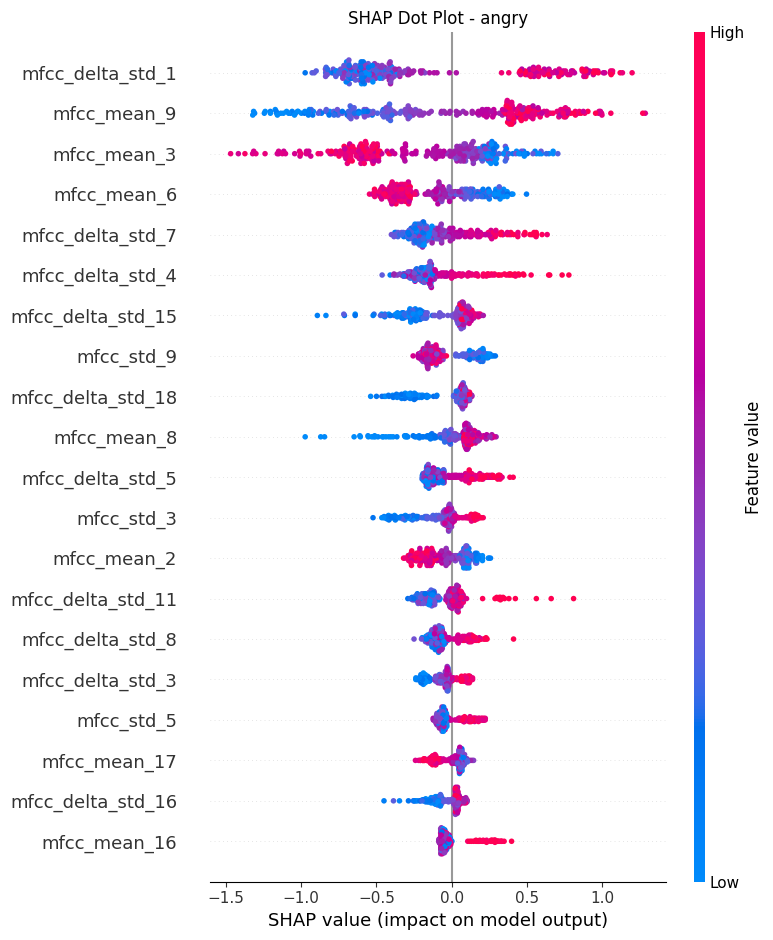

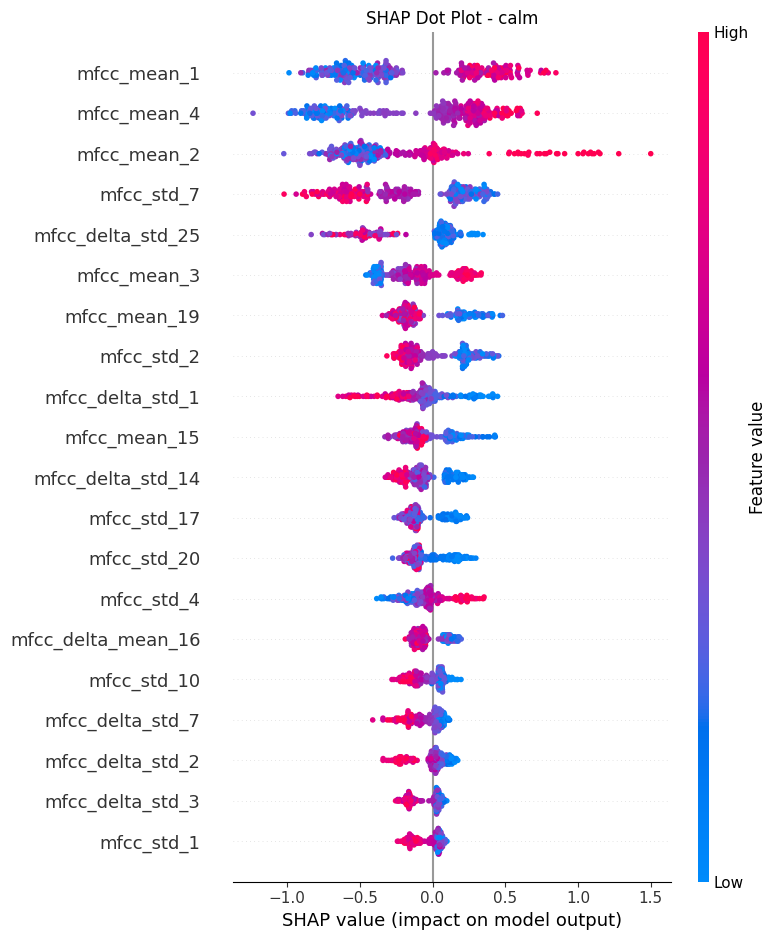

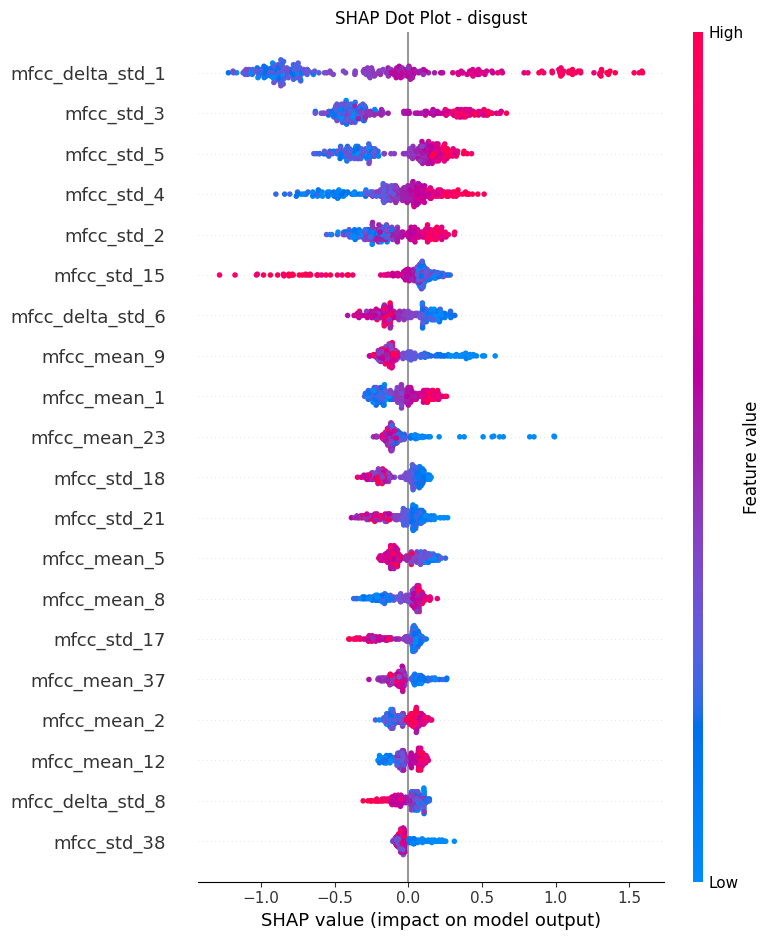

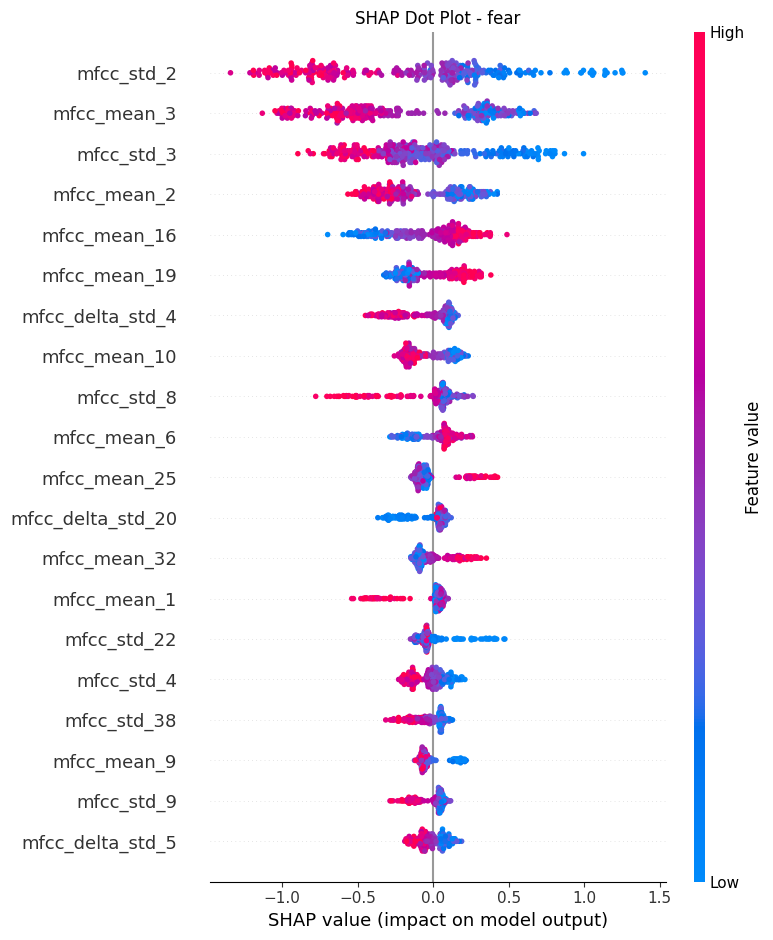

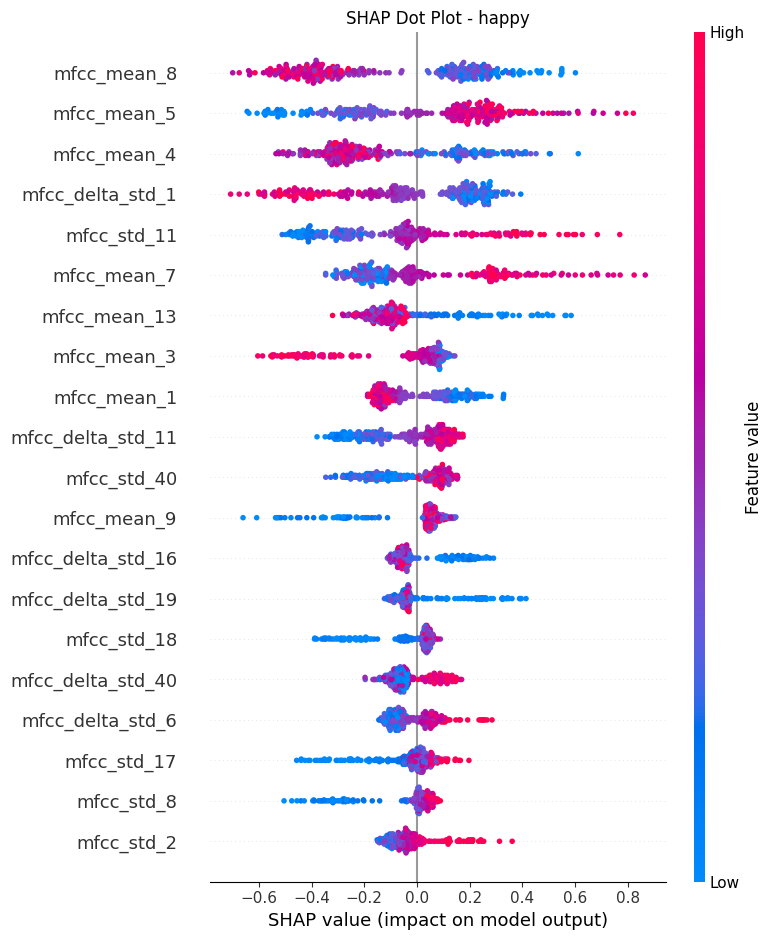

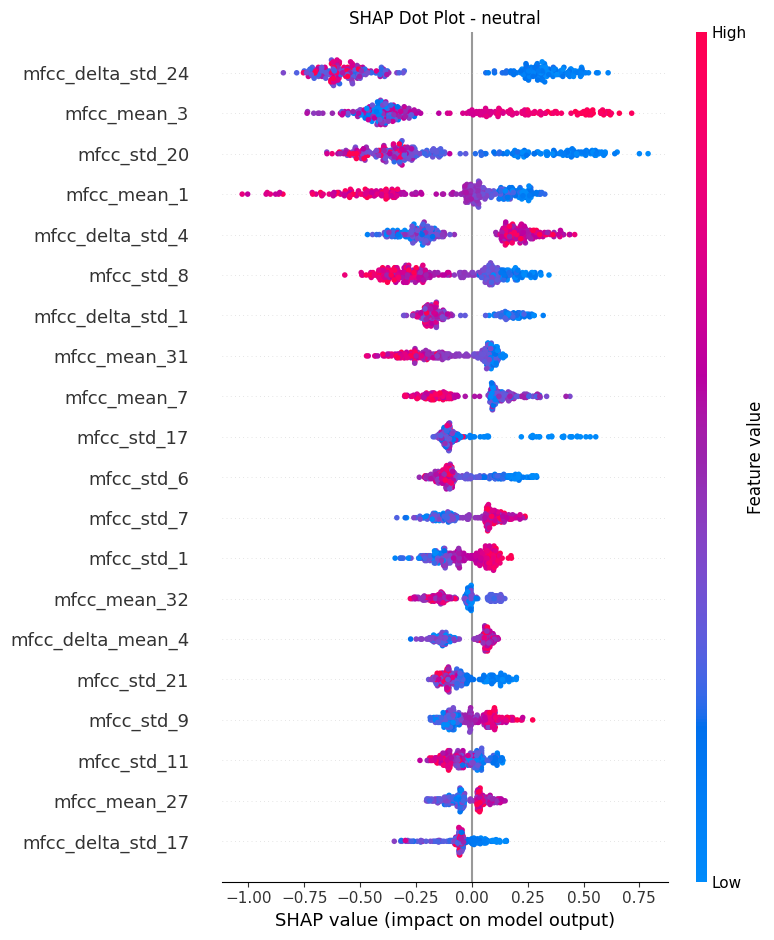

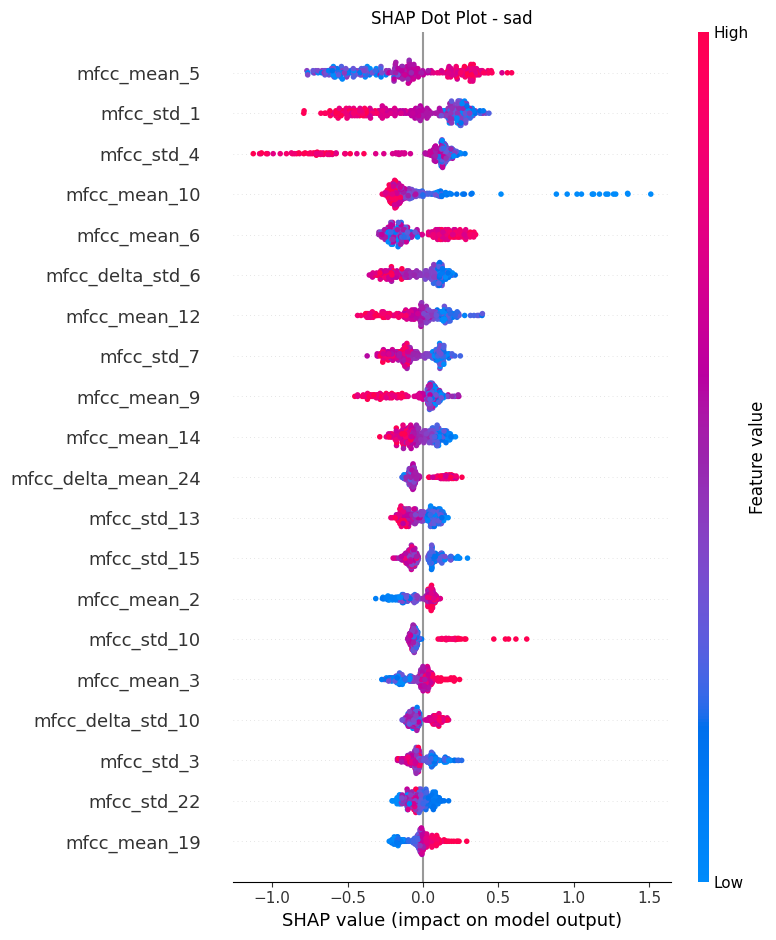

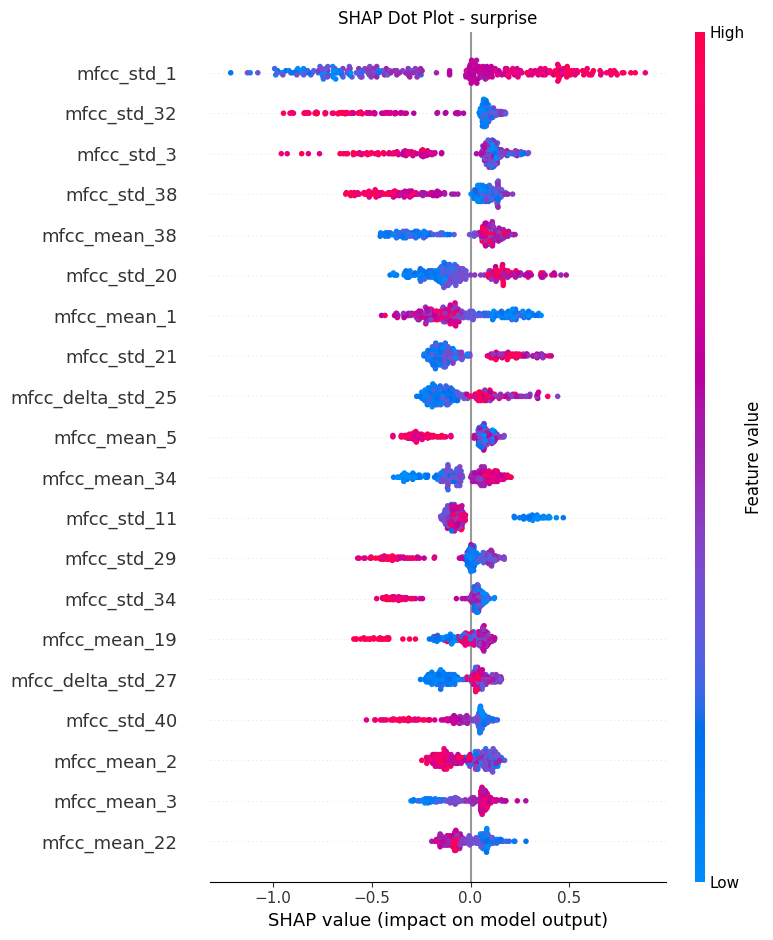

In [21]:
# Generate SHAP dot summary plot for every emotion in separate figures
for emotion_idx, emotion_name in enumerate(classes):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values[:, :, emotion_idx],
        X_test_scaled,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dot Plot - {emotion_name}")
    plt.tight_layout()
    plt.savefig(
        outputs_path / f"shap_dot_{emotion_name}.png",
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

## Issues with happy classification

The SHAP dot plot for the happy emotion contains a lot of information as to why it achieved the second lowest F1 score of 0.54 in our model.
Every single dot represents one audio clip from our test set. If a dot sits to the right of the center line, that feature pushed the model toward predicting happy for that clip. If it sits to the left, that feature pushed the model away from happy. The color tells us the actual value of that feature - red means the feature had a high value for that clip, and blue means it had a low value.

Let's start with the most important feature for happy - mfcc_mean_8.
The red dots - clips with high mfcc_mean_8 values - are almost entirely on the LEFT side, with SHAP values reaching as far as negative 0.6. This means that whenever this frequency band has high energy, the model is strongly pushed away from predicting happy. Meanwhile the blue dots - low mfcc_mean_8 values - spread to the RIGHT, supporting a happy prediction. In acoustic terms, high energy in band 8 is associated with tense, high-arousal emotions like anger and fear - not happiness. So the model has learned to associate high band 8 energy with not happy, which is acoustically correct.

Moving down to mfcc_mean_5, we see the opposite but equally consistent pattern. Blue dots stretch far to the right, meaning low mid-frequency energy supports a happy prediction. Red dots cluster on the left. This is again acoustically meaningful - happy speech tends to be bright and forward in quality, not heavy in mid-frequencies.

mfcc_mean_3 is an important factor here as well. The red dots reach as far left as negative 0.8, making it one of the strongest individual pushes away from happy in the entire plot. But from our global importance plot - mfcc_mean_3 was the single most important feature overall across all emotions. This creates a direct conflict: the feature that is most useful globally is actively working against happy classification specifically.
Because mfcc_mean_3 captures low-frequency vocal energy - and both happy and fear share elevated energy in this band. The model sees high mfcc_mean_3 and gets confused between the two emotions. This is the acoustic root cause of our biggest confusion matrix error - happy being misclassified as fear.

Notice also mfcc_delta_std_1, this is our second most globally important feature. Yet for happy, its dots are spread on both sides with no clear directional pattern. This means the model's temporal variability signal, which works so well for angry, provides almost no reliable guidance for happy. Happy speech does not have a consistent temporal signature that separates it from other emotions.

Another important observation is the width of the dot clouds. For features like mfcc_mean_8 and mfcc_mean_5, the dots spread widely across the x-axis - some reaching 0.8 in both directions. This wide spread indicates high variance - the model's response to these features is very different from clip to clip. This is a sign of inconsistency in what happy sounds like across different speakers and recording conditions in RAVDESS, making it inherently harder to classify.

### 4 - Per Emotion SHAP Comparison

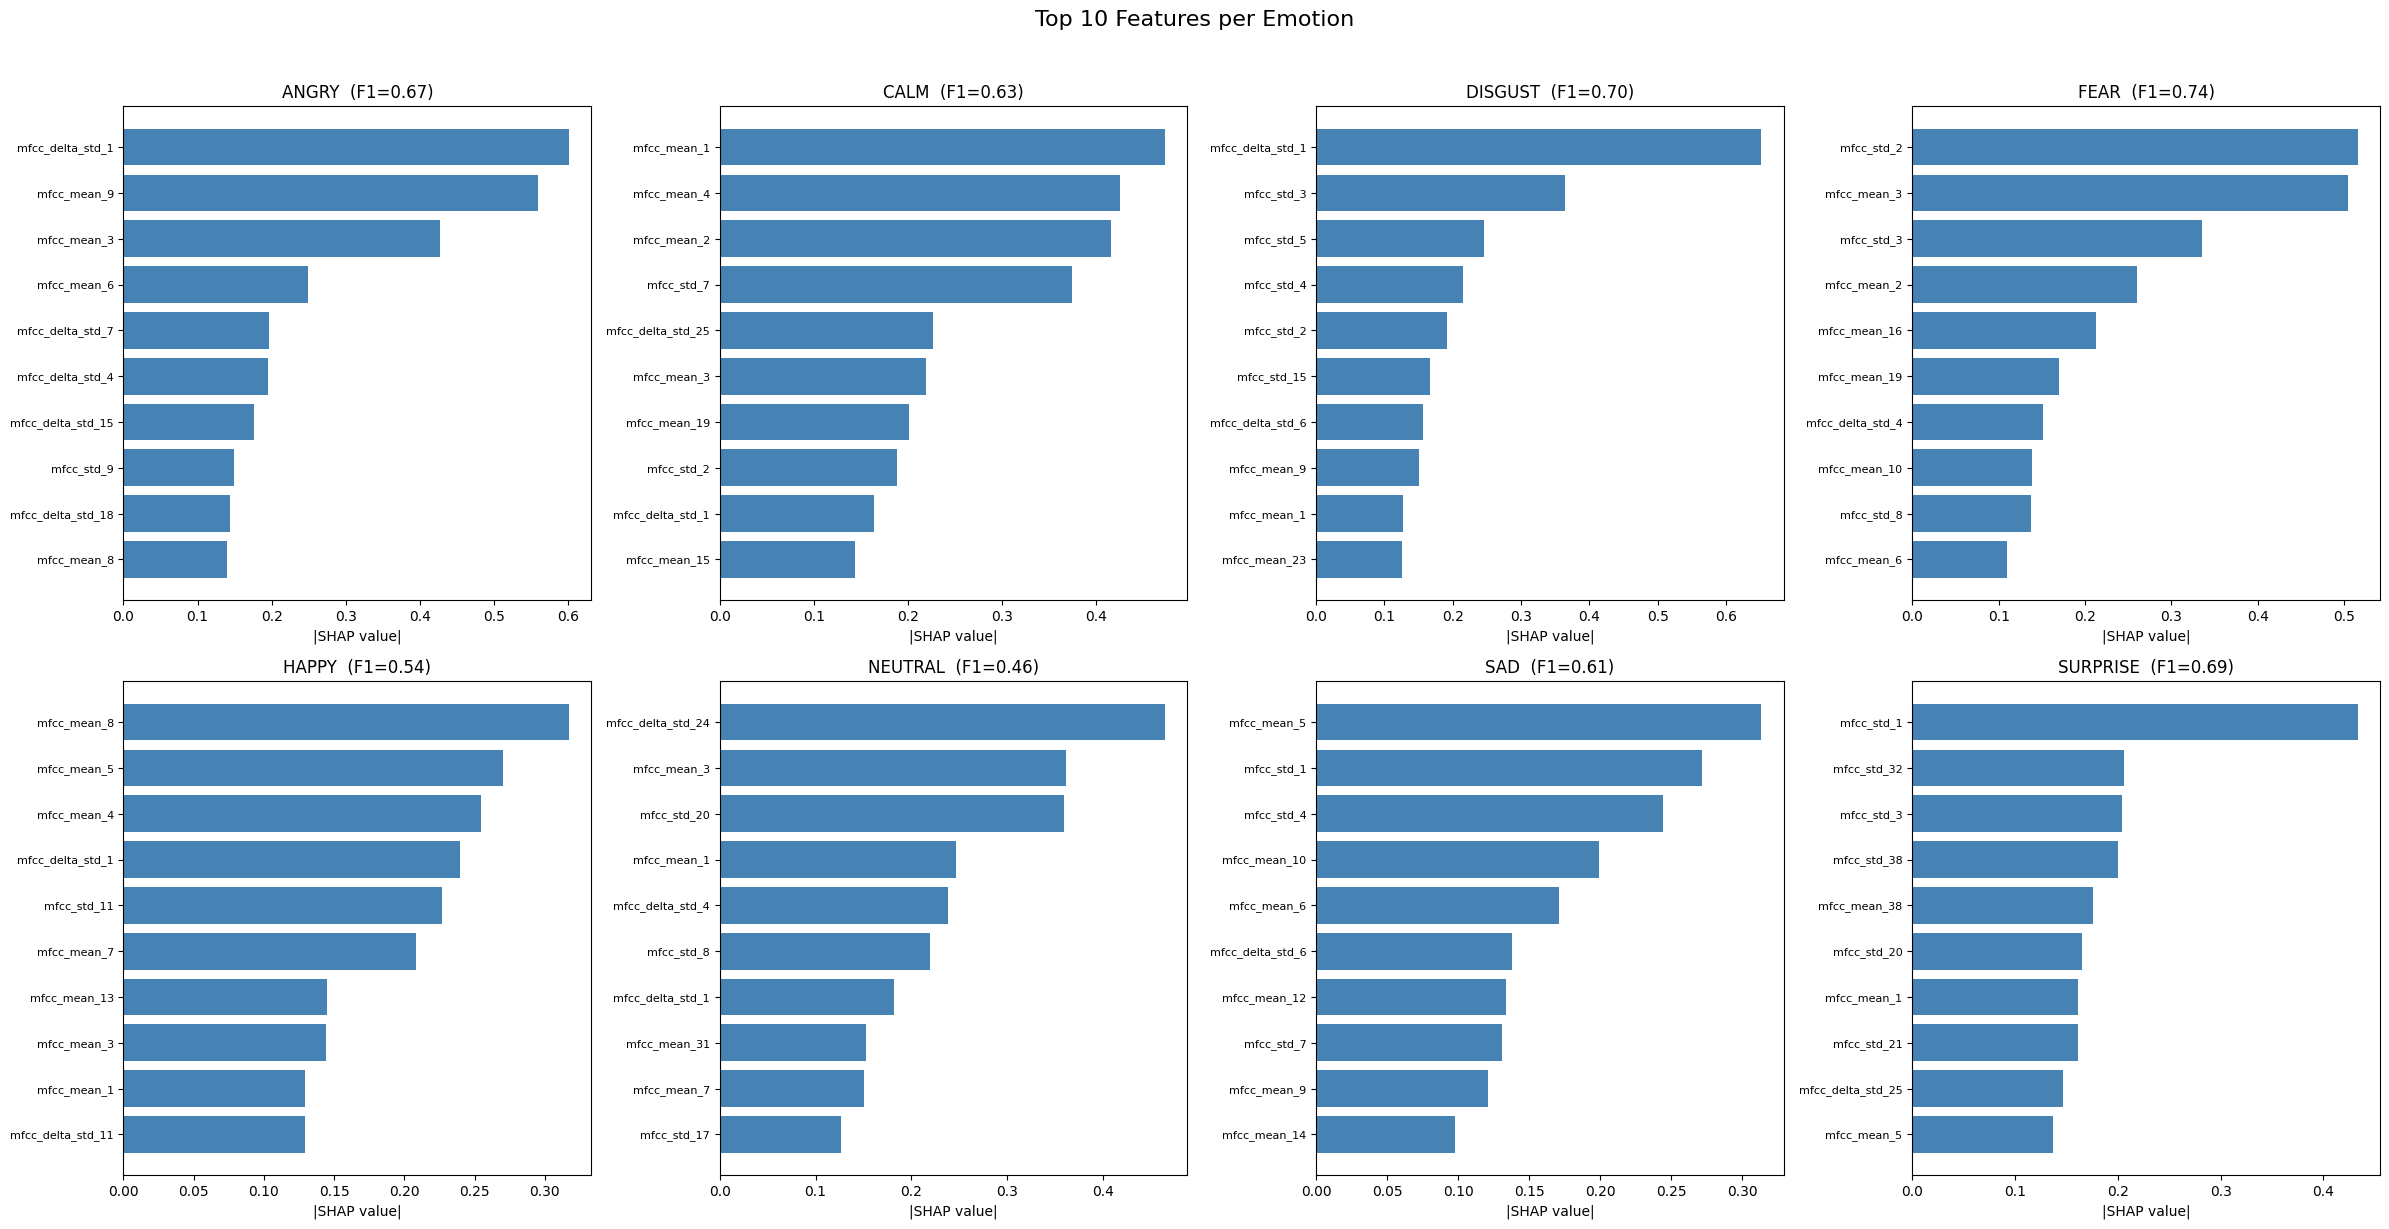

In [22]:
# Compare SHAP patterns across all 8 emotions
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, emotion in enumerate(classes):
    # Top 10 most important features for this emotion
    mean_shap = np.abs(shap_values[:, :, i]).mean(axis=0)
    top10_idx  = np.argsort(mean_shap)[::-1][:10]
    top10_vals = mean_shap[top10_idx]
    top10_names = [feature_names[j] for j in top10_idx]

    axes[i].barh(range(10), top10_vals[::-1], color='steelblue')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(top10_names[::-1], fontsize=8)
    axes[i].set_title(f"{emotion.upper()}  (F1={per_emotion_f1[i]:.2f})")
    axes[i].set_xlabel("|SHAP value|")

plt.suptitle("Top 10 Features per Emotion", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(outputs_path / "shap_per_emotion.png", dpi=150, bbox_inches='tight')
plt.show()

## Top 10 Features Per Emotion

**ANGRY - F1: 0.67**
Angry has the most distinctive feature profile of all eight emotions. Its single most important feature is mfcc_delta_std_1, with a SHAP value approaching 0.6.
What this tells us is that angry is not primarily defined by how the voice sounds on average, but by how erratically it changes over time. Angry speech is forceful, unpredictable, and rapidly shifting and mfcc_delta_std_1 captures exactly that temporal instability. Notice also that the top 10 for angry contains five delta_std features, more than any other emotion. Angry is the most temporally dynamic emotion in the dataset, and the model has learned this correctly.
This directly explains why angry achieves the highest recall, it has a unique, consistent temporal signature that no other emotion shares as strongly.

**CALM - F1: 0.63**
Calm shows a completely different profile. Its top features are almost entirely mean features - mfcc_mean_1, mfcc_mean_2, mfcc_mean_4 dominating the top three positions, with SHAP values between 0.35 and 0.5. These are all low-frequency tonal features.
This tells us calm is defined by its average spectral character - a steady, low-energy, consistent voice. Delta features on the other hand barely appear in calm's top 10, with only mfcc_delta_std_25 and mfcc_delta_std_1 present at the lower ranks. This is the acoustic opposite of angry - calm speech barely changes over time, and the model has captured that distinction beautifully.
However, the fact that calm relies on similar low-frequency mean features as neutral directly explains their confusion. Both emotions sound tonally similar, steady and quiet, and without strong temporal differentiation, the model struggles to separate them, which is exactly what our confusion matrix showed with 21% of neutral samples being called calm.

**DISGUST - F1: 0.70**
Disgust presents an interesting mixed profile. Its top feature is mfcc_delta_std_1 at 0.63 - even higher than angry's top feature. This is surprising and meaningful. Disgust, like angry, involves a strong temporal instability component. Both are negative, high-tension emotions with erratic vocal quality.
However, disgust's remaining features are almost entirely std features - mfcc_std_3, mfcc_std_5, mfcc_std_4, mfcc_std_2, mfcc_std_15 - measuring variability in spectral energy rather than the mean level itself. This suggests disgust is characterized by inconsistent, variable vocal quality rather than sustained high energy. The voice fluctuates in intensity but not necessarily in the same forceful way as angry.
This profile overlap between disgust and angry - both featuring mfcc_delta_std_1 prominently - directly explains the 18.4% of disgust samples being misclassified as angry in our confusion matrix.

**FEAR - F1: 0.74**
Fear achieves the highest F1 score of all eight emotions, and its feature profile explains why. Its top three features - mfcc_mean_3, mfcc_std_2, mfcc_std_3 - all have SHAP values between 0.30 and 0.50, creating a strong, well-defined acoustic signature.
Fear is characterized by both high average energy in low-frequency bands AND high variability in those same bands. The voice is simultaneously intense and unstable - which acoustically describes the tension and unpredictability of fearful speech perfectly. The combination of mean and std features working together gives the model enough discriminative power to classify fear more reliably than any other emotion.

**HAPPY - F1: 0.54**
Happy has one of the lowest F1 scores and its feature profile immediately shows why. Its top feature mfcc_mean_8 has a SHAP value of only 0.30 - the lowest top-feature value of any emotion in this entire plot. This means even the most important feature for happy provides relatively weak discriminative signal.
Furthermore, happy's top 10 is a scattered mix of mean features, std features, and delta_std features with no clear dominant type. Angry had a clear temporal signature. Calm had a clear mean signature. Fear had a clear combined signature. Happy has no consistent acoustic identity that separates it cleanly from other emotions. It borrows features from multiple emotion profiles without owning any of them uniquely.
This is the fundamental acoustic challenge - happy is a high-arousal positive emotion that shares spectral properties, making it inherently ambiguous to classify from MFCC features alone.

**NEUTRAL - F1: 0.46**
Neutral's most important feature is mfcc_delta_std_24, a higher-frequency temporal variability feature, followed by mfcc_std_20 - both are higher-index features that barely appeared in other emotions' top 10 lists. This is unique and telling.
Neutral speech has no strong low-frequency signal because it carries no emotional energy. The model is therefore forced to rely on subtle higher-frequency variability patterns to identify it - much weaker signals than what other emotions provide. With only 96 training samples - half the size of other classes - and weak acoustic signals, neutral being the lowest F1 at 0.46 is completely expected and explained by this feature profile.

**SAD - F1: 0.61**
Sad shows a profile dominated by mfcc_mean_5 at 0.32, followed by multiple std features - mfcc_std_1, mfcc_std_4, mfcc_std_10. Sad speech is characterized by low mid-frequency energy and moderate variability - a slow, heavy, somewhat trembling vocal quality.
The near-absence of delta features in sad's top 10 is meaningful. Sad speech changes slowly and predictably over time - there is little erratic temporal behavior. The model correctly identifies sad as a low-arousal, tonally subdued emotion, which is acoustically accurate.

**SURPRISE - F1: 0.69**
Surprise achieves a strong F1 score, and its feature profile is dominated by mfcc_std_1 at 0.40 - the variability of the lowest frequency band. What is particularly striking about surprise is that its top 10 contains an unusually high number of std features across a wide range of bands - mfcc_std_38, mfcc_std_3, mfcc_std_32, mfcc_std_21, mfcc_std_20 - spanning both low and high frequency ranges.
This tells us surprise is defined by broadband spectral variability - the entire voice becomes unpredictable and fluctuating across all frequencies simultaneously. This makes acoustic sense - surprise involves a sudden, full-voice exclamation that disrupts normal speech patterns across the entire frequency spectrum.

### Conclusion 
Stepping back and looking at all eight panels together, three major patterns emerge that are central to our XAI findings.
First, each emotion has a genuinely distinct feature profile. Angry relies on temporal instability in low bands. Calm relies on stable low-frequency means. Fear relies on both mean and variability in low bands. Surprise relies on broadband variability. This diversity confirms the model is learning real acoustic emotion signatures, not shortcuts.
Second, the emotions that share similar profiles are exactly the ones that confuse each other. Angry and disgust both feature mfcc_delta_std_1 prominently - 23.7% confusion. Fear and happy both feature low-frequency means - 20.5% confusion. Calm and neutral both rely on quiet, steady tonal features - 21.1% confusion. SHAP has given us the acoustic explanation for every major error in our confusion matrix.
Third, the feature types that dominate vary meaningfully by emotion. High-arousal negative emotions - angry, disgust - are primarily temporal. Low-arousal emotions - calm and sad - are primarily tonal means, while neutral is more dependent on subtle higher-frequency variability. Mixed emotions - fear, surprise - combine both. This pattern aligns perfectly with established acoustic psychology literature on emotion and validates that our model has learned acoustically meaningful representations.

### 5_Local Explanation (Misclassified Sample)

Sample index:  63
True label:    happy
Predicted:     fear


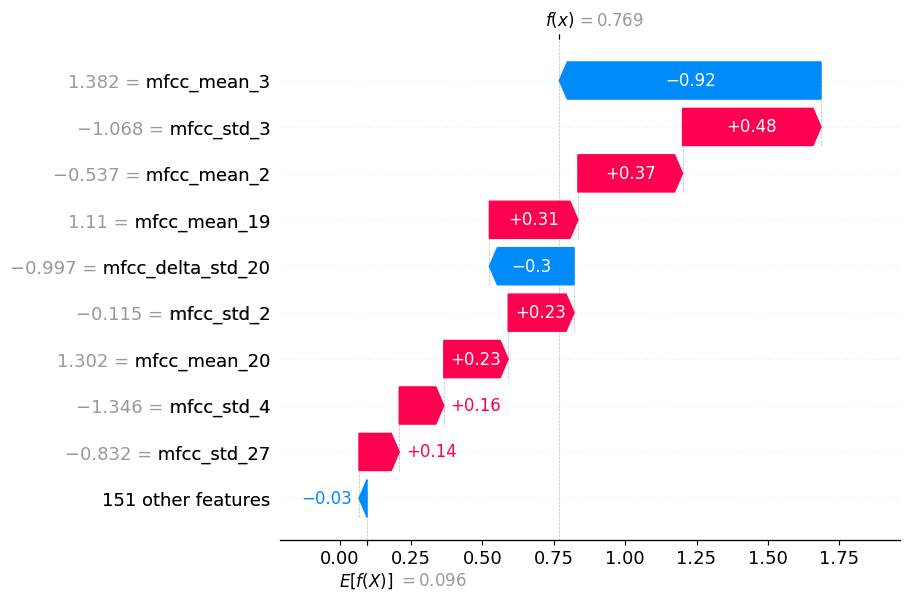

<Figure size 640x480 with 0 Axes>

In [23]:
# Find misclassified samples
y_pred_loaded = np.load(artifacts_path / "y_pred.npy")
wrong_indices = np.where(y_pred_loaded != y_test)[0]

# Focus on happy misclassified as fear (biggest confusion)
for idx in wrong_indices:
    if y_test[idx] == classes.index('happy') and \
       y_pred_loaded[idx] == classes.index('fear'):
        wrong_idx = idx
        break

print(f"Sample index:  {wrong_idx}")
print(f"True label:    {classes[y_test[wrong_idx]]}")
print(f"Predicted:     {classes[y_pred_loaded[wrong_idx]]}")

# Waterfall plot - why was this clip misclassified?
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[wrong_idx, :, y_pred_loaded[wrong_idx]],
        base_values=explainer.expected_value[y_pred_loaded[wrong_idx]],
        data=X_test_scaled[wrong_idx],
        feature_names=feature_names
    )
)
plt.savefig(outputs_path / "shap_waterfall_misclassified.png",
            dpi=150, bbox_inches='tight')
plt.show()

# SHAP Waterfall Plot

**E[f(X)] = 0.096**

This is the model's average output across all test samples.

**f(x) = 0.769**

This is the final prediction score for this specific clip.

A positive score means the model is predicting **FEAR** for this clip.


# True Label vs Prediction

| Item | Emotion |
|---|---|
| True emotion | HAPPY |
| Predicted emotion | FEAR |

This clip was a genuine happy recording that the model labeled as fear.

# Final Calculation

| Component | Contribution |
|---|---:|
| Starting baseline | 0.096 |
| `mfcc_mean_3` | -0.92 |
| `mfcc_std_3` | +0.48 |
| `mfcc_mean_2` | +0.37 |
| `mfcc_mean_19` | +0.31 |
| `mfcc_delta_std_20` | -0.30 |
| `mfcc_std_2` | +0.23 |
| `mfcc_mean_20` | +0.23 |
| `mfcc_std_4` | +0.16 |
| `mfcc_std_27` | +0.14 |
| 151 other features | -0.03 |
| **Final prediction score** | **0.769** |

**Final classification: FEAR**

---

# What This Misclassification Teaches Us

This single example reveals three important insights that go beyond just one wrong prediction.

## 1. The Misclassification Has a Logical Explanation

This was not a random error.

The model made a systematic mistake based on real acoustic overlap between happy and fear.

Although `mfcc_mean_3` strongly argues against fear, several other features (`mfcc_std_3`, `mfcc_mean_2`, `mfcc_mean_19`, `mfcc_std_2`, `mfcc_mean_20`) collectively push the score above the fear decision boundary.

A human listener might have recognized emotional context differently, but MFCC-based features reduce the clip to acoustic statistics.

---

## 2. The Model Shows Competing Signals

The conflict between strong negative and positive contributors in the same prediction is the key pattern.

For example:

- `mfcc_mean_3 = -0.92` (away from fear)
- `mfcc_std_3 = +0.48` and `mfcc_mean_2 = +0.37` (toward fear)

This suggests the misclassification is produced by a balance of opposing acoustic cues, not one single faulty feature.

---

## 3. This Supports the Need for CNN + Grad-CAM

This is exactly the type of error that a CNN operating on full mel spectrograms may help address.

The CNN does not simply average features across time. Instead, it sees the full temporal evolution of the sound.

A happy clip may have a different temporal shape from a fearful one, even if their averaged MFCC statistics look similar.

Therefore, this waterfall plot provides a strong argument for the next phase of the project:

**using CNNs with Grad-CAM to overcome the limitations identified by SHAP.**

### 6 - SHAP Heatmap (Most Powerful Visual)

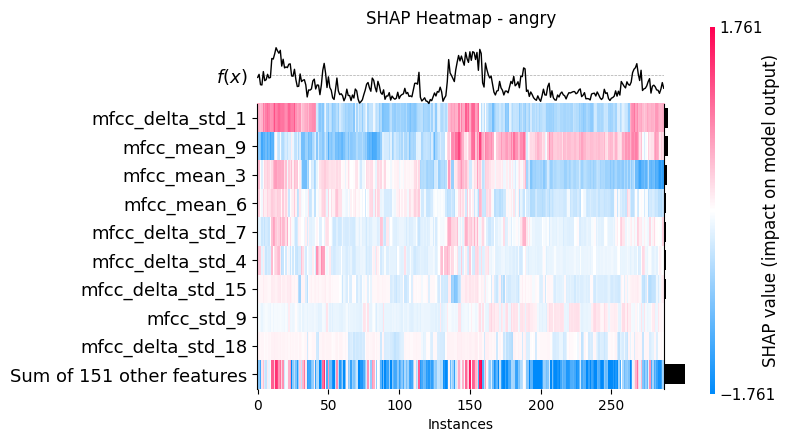

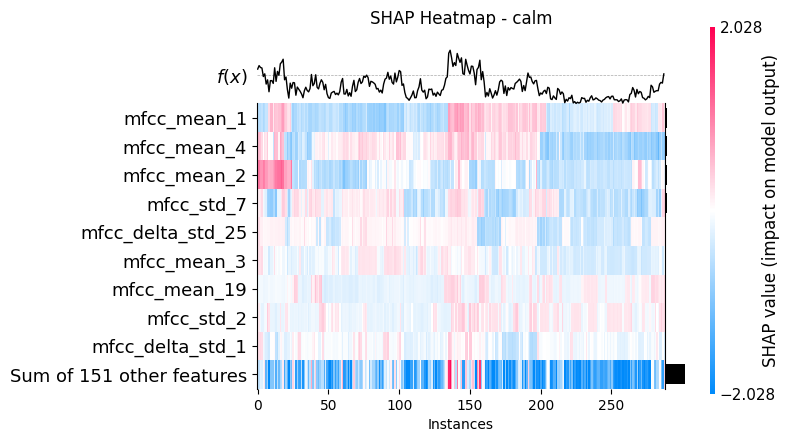

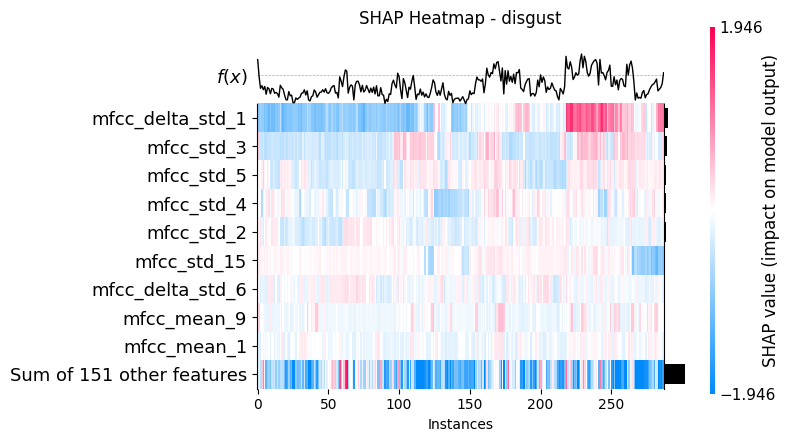

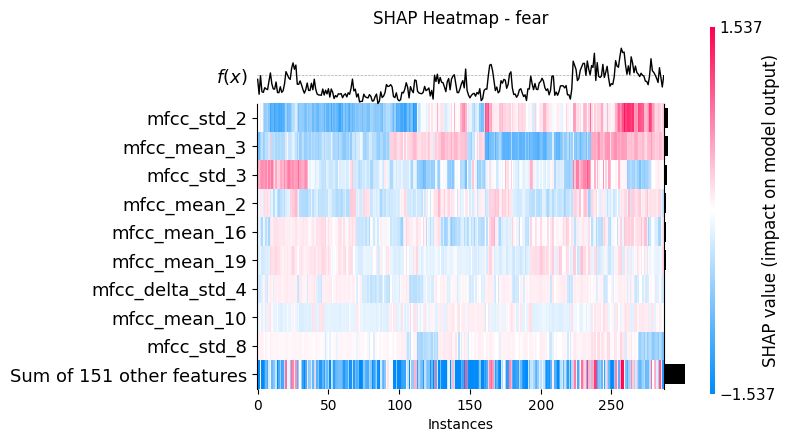

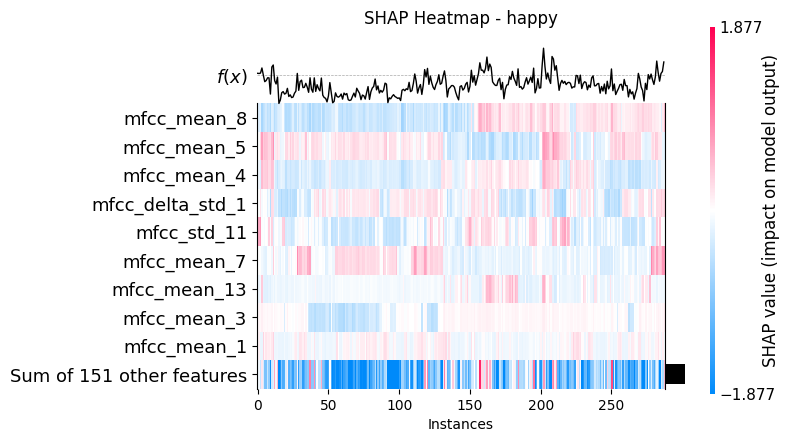

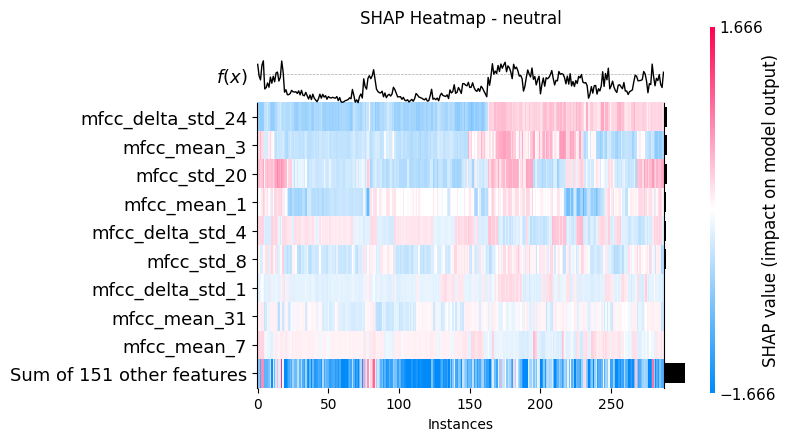

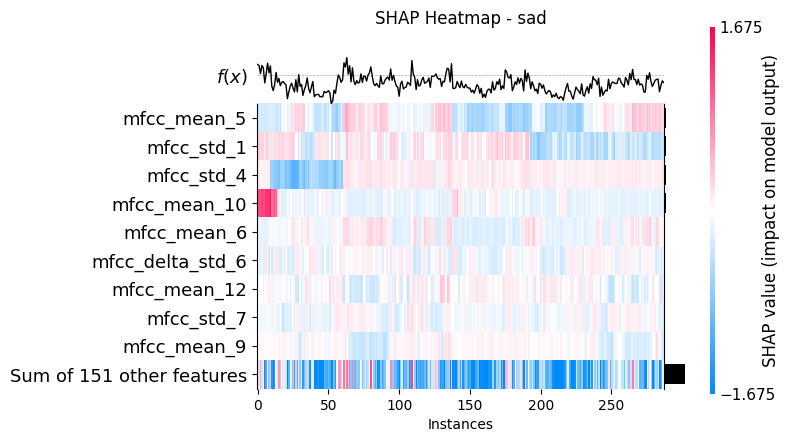

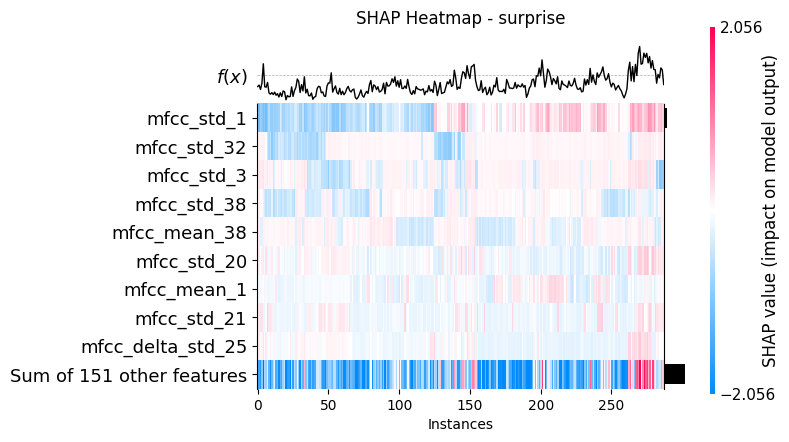

In [24]:
for emotion_idx, emotion_name in enumerate(classes):
    plt.figure(figsize=(12, 8))
    shap.plots.heatmap(
        shap.Explanation(
            values=shap_values[:, :, emotion_idx],
            base_values=explainer.expected_value[emotion_idx],
            data=X_test_scaled,
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"SHAP Heatmap - {emotion_name}")
    plt.tight_layout()
    plt.savefig(
        outputs_path / f"shap_heatmap_{emotion_name}.png",
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

# SHAP Heatmap for Angry Emotion

The f(x) Line - Model Confidence Across All Clips

Left region (instances 0-100):
  Line fluctuates with several sharp peaks
  - model alternates between confident angry
    and confident not-angry
  - genuine angry clips mixed with other emotions

Middle region (instances 100-200):
  Line drops lower with fewer peaks
  - fewer angry clips in this region
  - model correctly suppressing angry predictions

Right region (instances 200-280):
  Line rises again with clear peaks
  - another cluster of angry clips
  - model picking them up reliably
The key observation is that the peaks in the f(x) line are sharp and distinct - not gradual. When the model decides something is angry, it decides with conviction. This is the acoustic clarity of anger - it has a strong enough signature that the model is rarely uncertain. It is either clearly angry or clearly not angry, with little ambiguity in between. This is why angry achieves the highest recall of 78.9% despite having an overall model F1 of only 0.631."

## Feature by Feature Analysis

**mfcc_delta_std_1 - Row 1 (Most Important)**

The pattern is remarkably clear:
  - Deep RED columns → these clips scored high on delta_std_1
                     model pushes strongly toward angry
                     these are the true angry clips

  - Deep BLUE columns → low delta_std_1 values
                      model pushes strongly away from angry
                      these are non-angry clips

Crucially: the RED and BLUE columns align almost perfectly
with the peaks and valleys of the f(x) line above
This near-perfect alignment between mfcc_delta_std_1 and the overall prediction confirms it as the anchor feature for angry recognition. When this one feature is red, the model predicts angry. When it is blue, the model predicts something else. No other feature in the dataset shows this level of consistent alignment for any emotion - it is the clearest single-feature signal we found in the entire analysis."

**mfcc_mean_9 - Row 2**

The second row shows mfcc_mean_9 - the average energy in frequency band 9. Its pattern is notably different from delta_std_1.
  - Strong RED patches around instances 130-160
  → a specific cluster of angry clips has
    distinctively high band 9 energy

- Otherwise mostly pale/light blue
  → band 9 energy is only occasionally
    a strong signal for angry

This tells us mfcc_mean_9 is a supporting feature
not a primary one - it activates strongly for
some angry clips but not all of them
This partial activation pattern is acoustically meaningful - not all angry speech has the same spectral profile. Some angry utterances are high-pitched and tense, activating band 9. Others are low and growling, relying more on bands 1-3. The model has learned to use mfcc_mean_9 as a secondary confirmation signal when available."

**mfcc_mean_3 and mfcc_mean_6 - Rows 3 and 4**

Rows 3 and 4 show the mean features for bands 3 and 6. Their patterns are more diffuse than the delta features - lighter shades of pink and blue spread more evenly across instances rather than sharp contrasting columns.
mfcc_mean_3:  moderate pink for most clips
              occasional blue patches
              → contributes steadily but modestly
              → base tonal energy helps but
                is not the defining angry signal

mfcc_mean_6:  similar diffuse pattern
              slightly more blue than pink overall
              → band 6 energy slightly suppresses
                angry prediction on average
              → mid-frequency range is less
                diagnostic for anger
This diffuse pattern for mean features versus the sharp pattern for delta features visually confirms our core finding - angry is primarily a temporal emotion, not a tonal one."

**Delta_std Features - Rows 5 through 8**

Now look at rows 5, 6, 7 and 8 - mfcc_delta_std_4, mfcc_delta_std_7, mfcc_delta_std_15, and mfcc_delta_std_18. These are four additional temporal variability features across different frequency bands.
All four share a similar pattern:
  Moderate RED columns that roughly align
  with the peaks in the f(x) line
  
  Paler, less intense than mfcc_delta_std_1
  but consistently pointing in the same direction

Together they form a CHORUS of temporal signals:
  - delta_std_1  → band 1  temporal variability
  - delta_std_4  → band 4  temporal variability
  - delta_std_7  → band 7  temporal variability
  - delta_std_15 → band 15 temporal variability
  - delta_std_18 → band 18 temporal variability
The fact that temporal variability features appear across bands 1, 4, 7, 15 and 18 - spanning low to mid-high frequencies - tells us that angry speech is temporally unstable across the entire vocal frequency range simultaneously, not just in one narrow band. The whole voice becomes erratic when someone is angry, and the model has learned to look for that broadband temporal instability as the defining signature of anger."

**mfcc_std_3 - Row 9**

Row 9 shows mfcc_std_3 - the variability of band 3 energy. Its pattern is mostly pale blue, meaning it generally pushes slightly away from angry predictions.
This is counterintuitive at first glance -
we said angry involves vocal variability,
so why does std_3 push away from angry?

The answer lies in the difference between
std and delta_std:

mfcc_std_3    = overall variability of band 3
                across the entire clip
                angry clips may have high AVERAGE
                band 3 energy that is also steady
                in its own erratic way

mfcc_delta_std_1 = variability of the RATE OF CHANGE
                   captures moment-to-moment
                   unpredictability more precisely

The model has learned that delta_std captures
angry's temporal signature better than plain std
This is a subtle but important XAI finding 

## The Complete Angry Story

Stepping back from the individual rows, this heatmap tells a complete and coherent story about how the model recognizes anger.

**The model's angry detection is driven by a cascade of temporal signals.** When mfcc_delta_std_1 fires red, the other delta_std features typically follow - 4, 7, 15, 18 all lighting up moderately red together. This cascade of temporal instability across multiple frequency bands simultaneously is what the model has learned to recognize as the acoustic fingerprint of anger. It is not one feature - it is a coordinated pattern across the entire temporal structure of the voice.

**The mean features play a secondary, supporting role.** mfcc_mean_9 occasionally confirms the prediction when band 9 energy is high, and mfcc_mean_3 provides a steady baseline contribution. But neither is the trigger - they are the context that helps once the temporal signal has already fired.

**The model is decisive about anger.** The sharp transitions between deep red and deep blue - with very little pale middle ground - show that angry clips are acoustically distinct enough that the model commits to its prediction strongly. This is why angry has the highest recall in our confusion matrix despite not having the highest F1 score overall.

And finally, this heatmap gives us our strongest visual evidence for why moving to Phase 2 matters. Everything we see here - these temporal patterns, these cascading activations - are patterns in time. The MFCC features summarize them imperfectly into averaged statistics. A CNN operating on the full mel spectrogram will see these temporal patterns directly, as visual structures in a 2D image. Grad-CAM will then show us exactly which regions of that image the network focuses on - and we expect it to highlight precisely the time segments where these delta features would have been most active."

